In [370]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy
from scipy.linalg import inv
from sklearn.preprocessing import StandardScaler
from scipy.stats import kurtosis
from sklearn.decomposition import FastICA
from factor_analyzer import FactorAnalyzer
from scipy.stats import chi2
from scipy.stats import norm
import scipy.stats as stats
from sklearn.decomposition import PCA
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity, calculate_kmo
from sklearn.cluster import KMeans
from sklearn.covariance import EmpiricalCovariance
from sklearn.metrics import accuracy_score
from scipy.optimize import linear_sum_assignment
from sklearn.covariance import MinCovDet
from sklearn.model_selection import cross_val_score, StratifiedKFold
from scipy.spatial.distance import mahalanobis
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import KFold


np.set_printoptions(precision=4, suppress=True)

In [371]:
df = pd.read_csv('nhanes_data.csv')
print(f"Samples: {len(df)}, Variables: {df.shape[1]}")
# Numeric features for multivariate analysis (excluding ID)
num_cols = ['age', 'height_cm', 'weight_kg', 'waist_cm', 'bmi',
'systolic_bp', 'diastolic_bp', 'total_cholesterol',
'hdl_cholesterol', 'creatinine', 'glycohemoglobin']
X = df[num_cols].dropna()
# X = df[num_cols].copy()
# X = X.fillna(X.mean())

print(f"Complete cases: {len(X)}")

Samples: 5367, Variables: 16
Complete cases: 4931


missing values

In [372]:
missing_count = X.isnull().sum()
missing_percent = (X.isnull().mean() * 100)

missing_summary = pd.DataFrame({'Missing Count': missing_count, 'Missing %': missing_percent})

print(missing_summary)

print(f"Total missing values: {X.isnull().sum().sum()}")

                   Missing Count  Missing %
age                            0        0.0
height_cm                      0        0.0
weight_kg                      0        0.0
waist_cm                       0        0.0
bmi                            0        0.0
systolic_bp                    0        0.0
diastolic_bp                   0        0.0
total_cholesterol              0        0.0
hdl_cholesterol                0        0.0
creatinine                     0        0.0
glycohemoglobin                0        0.0
Total missing values: 0


Outliers

In [373]:
X_np = X.values
mu = np.mean(X_np, axis=0)
sigma = np.cov(X_np, rowvar=False)
sigma_inv = np.linalg.inv(sigma)
# Mahalanobis distance 
md = np.sqrt(np.sum((X_np - mu) @ sigma_inv * (X_np - mu), axis=1))
md_squared = md**2
# threshold
p = X_np.shape[1]
threshold = chi2.ppf(0.975, df=p)
# outliers
outliers = md_squared > threshold
print(f"Number of outliers based on Mahalanobis distance: {np.sum(outliers)}")

Number of outliers based on Mahalanobis distance: 345


In [374]:
z_scores = np.abs((X - X.mean()) / X.std())
thresh = 4
outlier = (z_scores > thresh)
outlier_counts = outlier.sum()
print(outlier_counts)
total_outliers = outlier.sum().sum()
total_values = X.shape[0] * X.shape[1]
print("total outliers:", total_outliers)

age                   0
height_cm             0
weight_kg            18
waist_cm              2
bmi                  18
systolic_bp          12
diastolic_bp         30
total_cholesterol     7
hdl_cholesterol      16
creatinine           20
glycohemoglobin      79
dtype: int64
total outliers: 202


In [375]:
#X = X[~outliers]

Boxplot

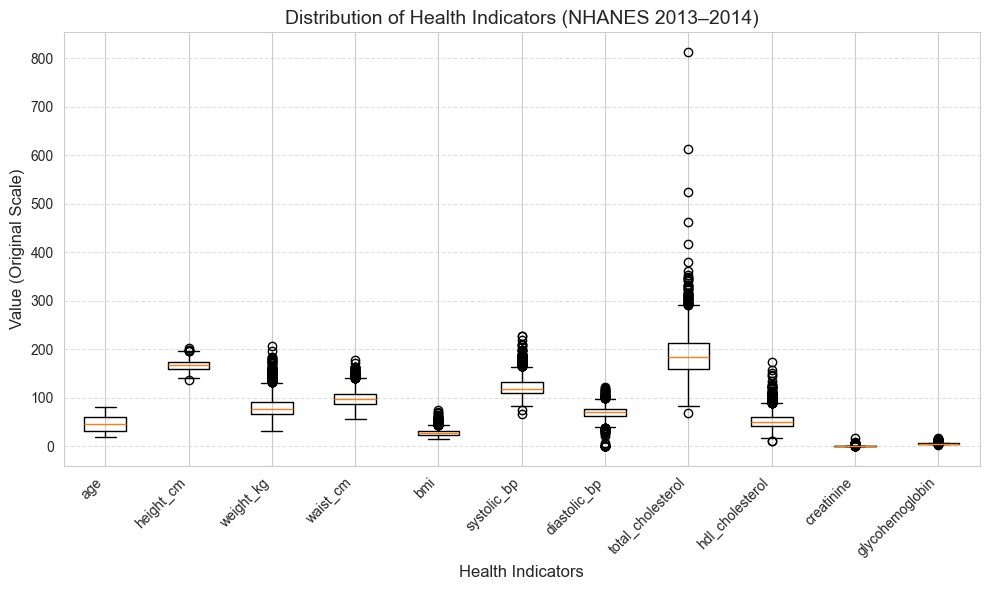

In [376]:
plt.figure(figsize=(10, 6))
box = plt.boxplot(X.values, tick_labels=X.columns)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.title("Distribution of Health Indicators (NHANES 2013–2014)", fontsize=14)
plt.xlabel("Health Indicators", fontsize=12)
plt.ylabel("Value (Original Scale)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Correlation Matrix

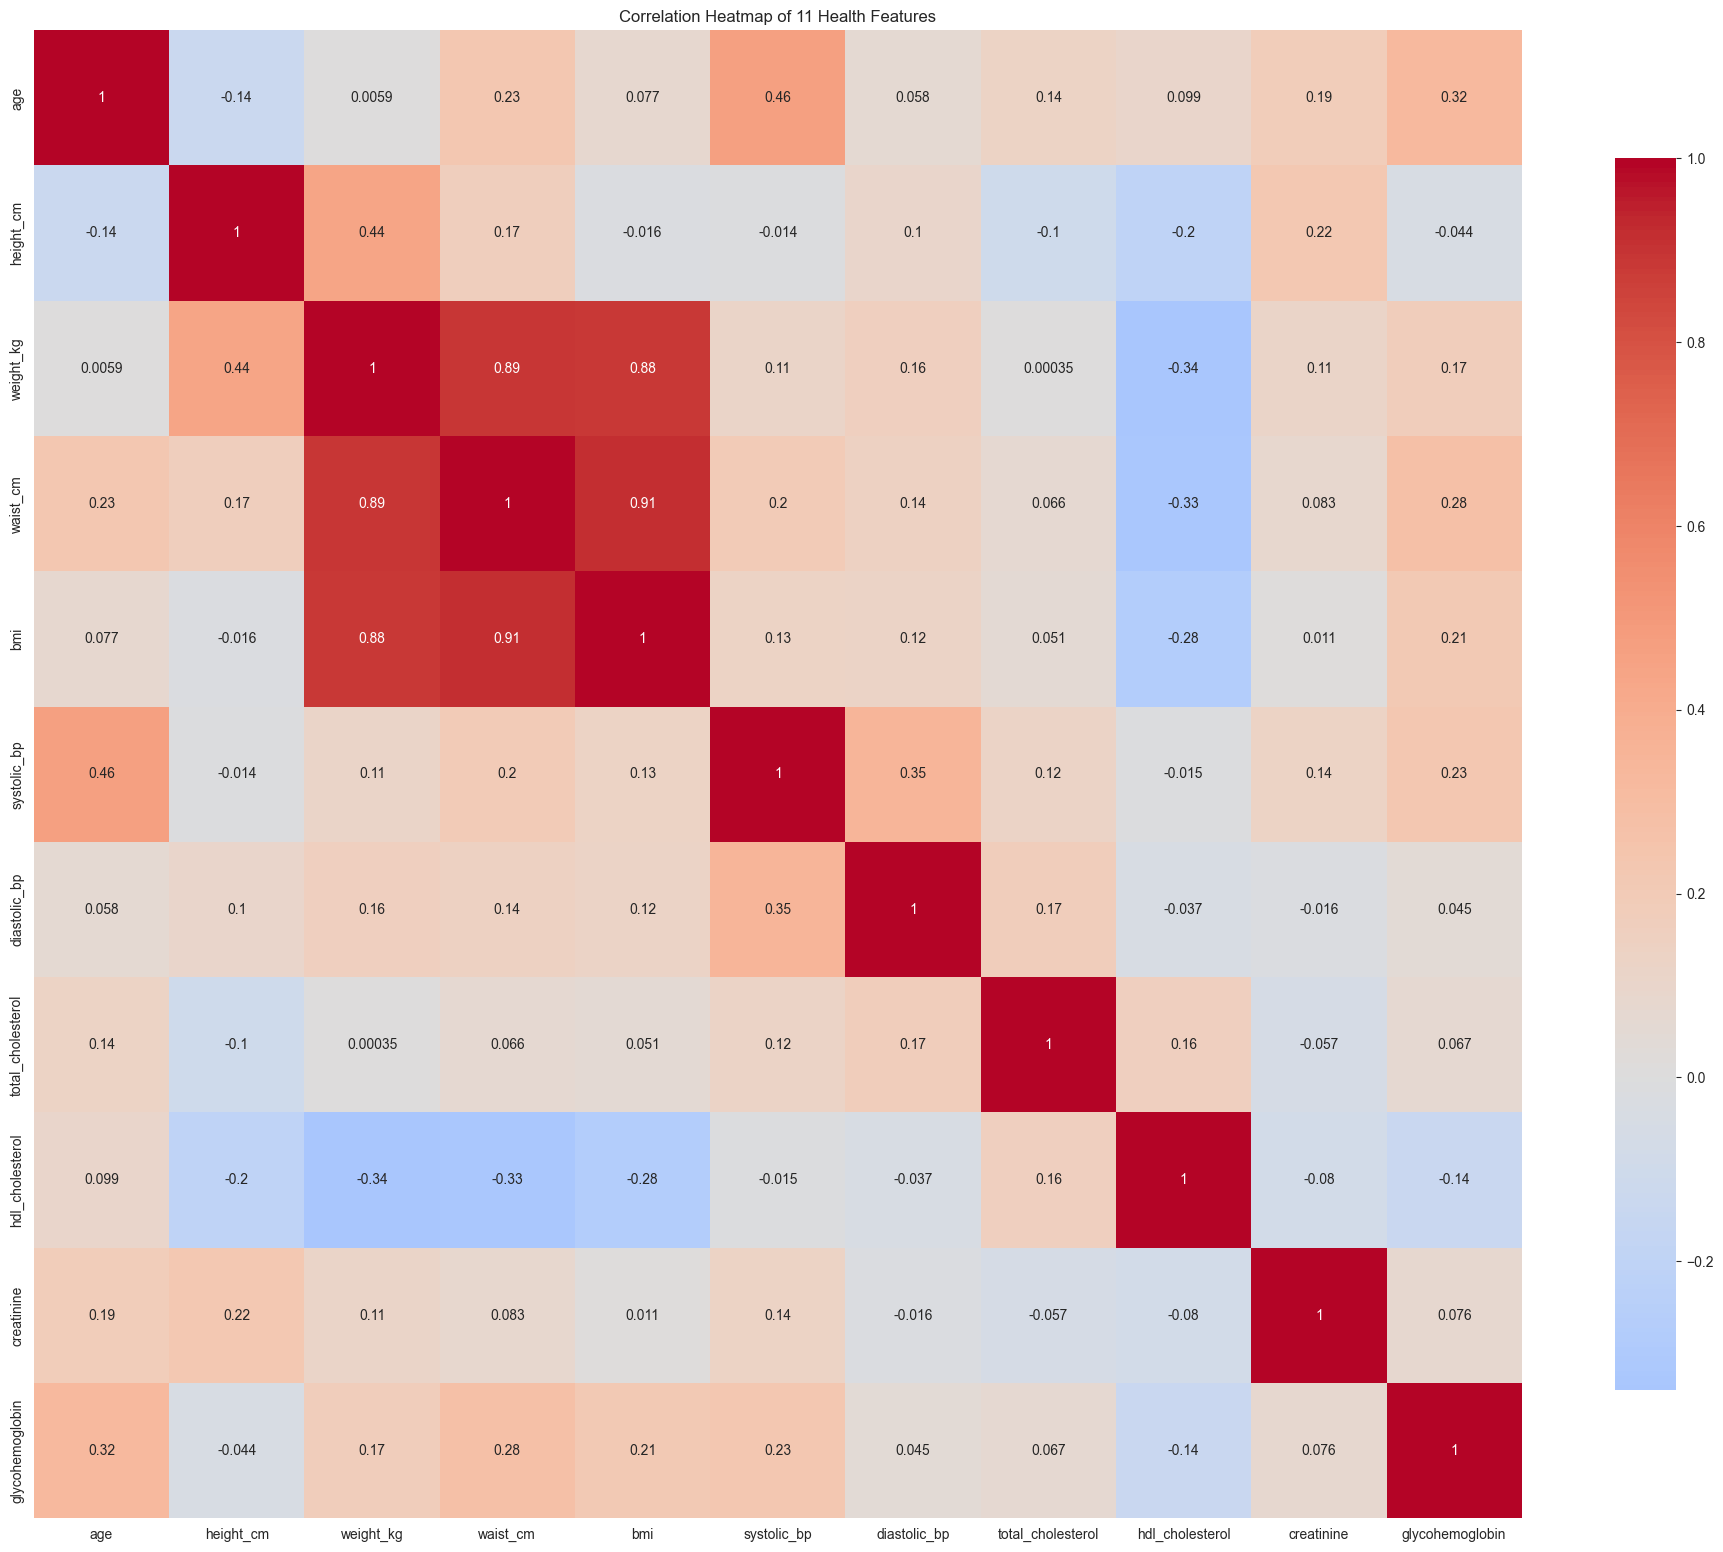

In [377]:
corr_matrix = X.corr()
plt.figure(figsize=(24,20))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=True, center=0, square=True, cbar_kws={"shrink": 0.8})
plt.title("Correlation Heatmap of 11 Health Features")
plt.show()

Mardia Test

In [378]:
def mardia_test(X):
    n, p = X.shape
    Xc = X - X.mean(axis=0)
    Xc_mat = Xc.to_numpy() if hasattr(X, "to_numpy") else np.asarray(X)
    S = (Xc_mat.T @ Xc_mat) / n
    S += np.eye(p) * 1e-6
    S_inv = np.linalg.inv(S)
    d = np.sum((Xc_mat @ S_inv) * Xc_mat, axis=1)
    b2p = np.mean(d**2)
    z_kurt = (b2p - p*(p+2)) / np.sqrt(8*p*(p+2)/n)
    pval_kurt = 1 - norm.cdf(z_kurt)
    b1p = 0.0
    batch = 2000
    for i in range(0, n, batch):
        Xi = Xc_mat[i:i+batch] @ S_inv
        A_block = Xi @ Xc_mat.T
        b1p += np.sum(A_block**3)
    chi2_skew = n * b1p / 6
    df_skew = p * (p + 1) * (p + 2) / 6
    pval_skew = 1 - chi2.cdf(chi2_skew, df_skew)
    return {"b1p": b1p, "skew_pvalue": pval_skew,"b2p": b2p,"kurt_pvalue": pval_kurt}
print(mardia_test(X))

{'b1p': np.float64(8150633559.156017), 'skew_pvalue': np.float64(0.0), 'b2p': np.float64(744.3640782218307), 'kurt_pvalue': np.float64(0.0)}


In [379]:
n, p = X.shape
Xc = X - X.mean()
Xc_mat = Xc.to_numpy()
S = np.cov(Xc_mat, rowvar=False)
S += np.eye(p) * 1e-6
S_inv = np.linalg.inv(S)
# Mahalanobis distances
d = np.sum((Xc_mat @ S_inv) * Xc_mat, axis=1)
# Mardia's Kurtosis
b2p = np.mean(d**2)
z_kurt = (b2p - p * (p + 2)) / np.sqrt(8 * p * (p + 2) / n)
pval_kurt = 1 - norm.cdf(z_kurt, loc=0, scale=1)
# Mardia's Skewness
A = Xc_mat @ S_inv @ Xc_mat.T
b1p = np.sum(A**3) / n ** 2
chi2_skew = n * b1p / 6
df_skew = p * (p + 1) * (p + 2) / 6
pval_skew = 1 - chi2.cdf(chi2_skew, df_skew)

print("Mardia Skewness (b1p):", b1p)
print("Skewness p-value:", pval_skew)
print("Mardia Kurtosis (b2p):", b2p)
print("Kurtosis p-value:", pval_kurt)

Mardia Skewness (b1p): 335.00949401574076
Skewness p-value: 0.0
Mardia Kurtosis (b2p): 744.0621981603725
Kurtosis p-value: 0.0


QQ plot

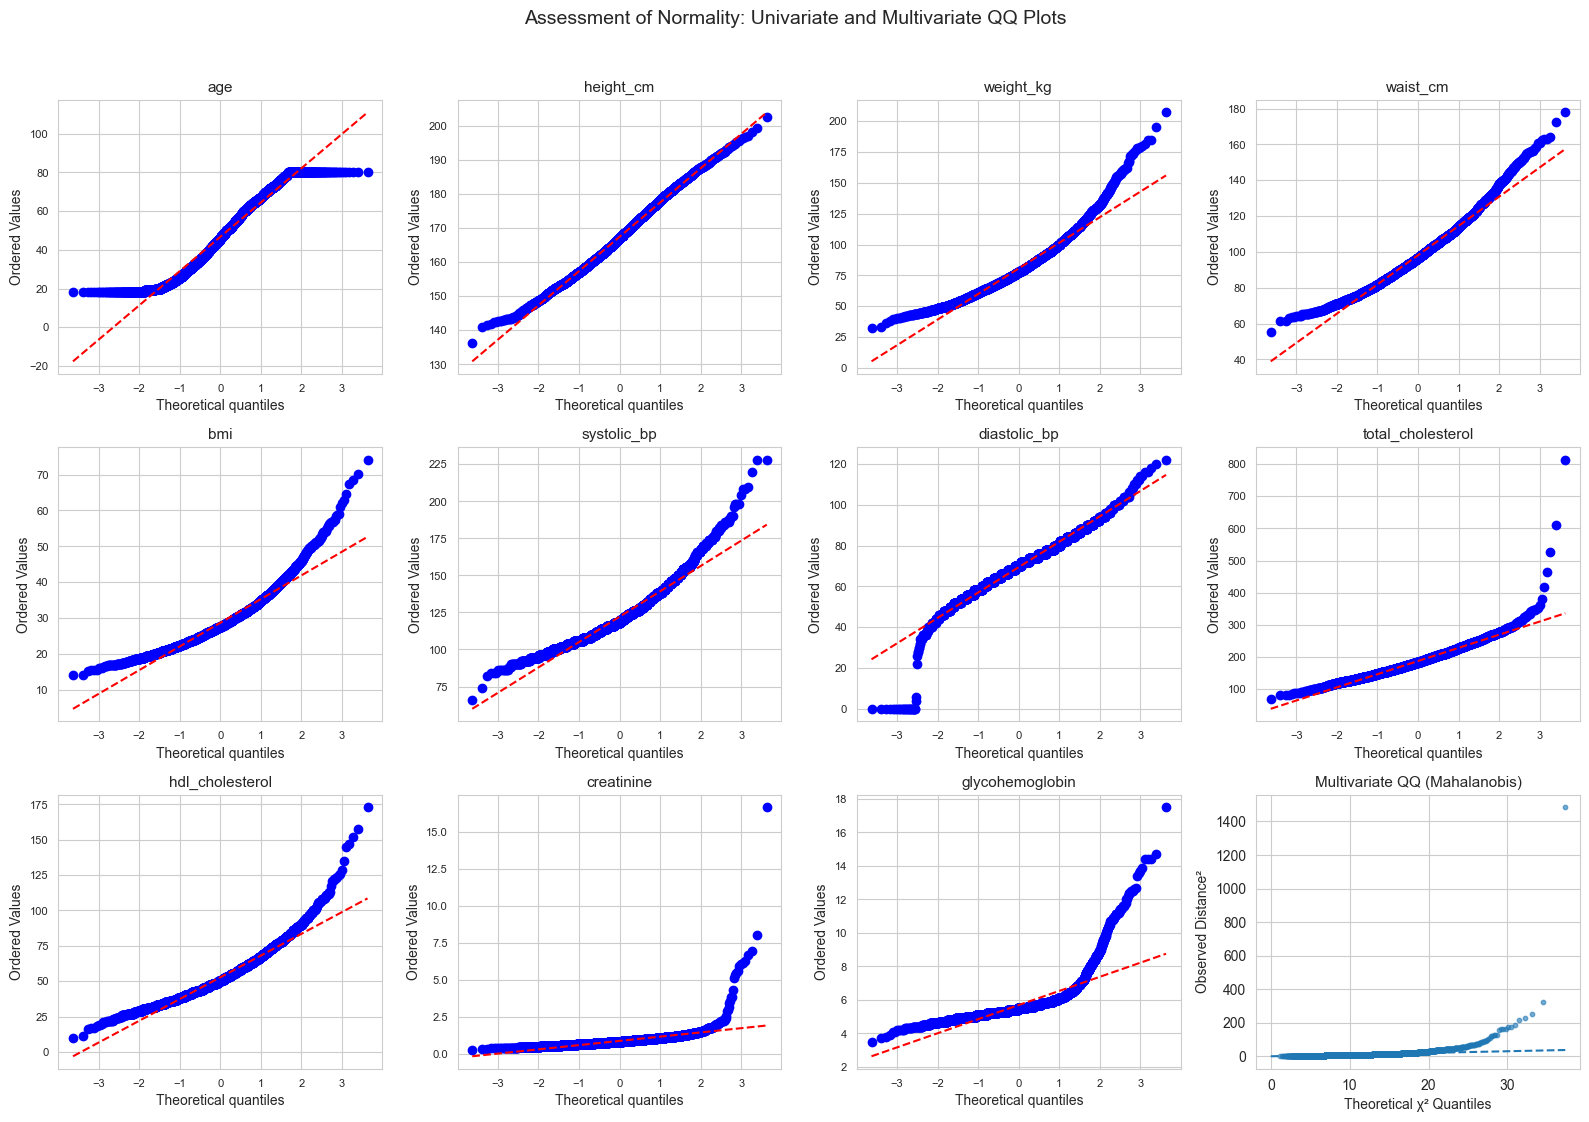

In [380]:
num_vars = num_cols
X = df[num_vars].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
cov = EmpiricalCovariance().fit(X_scaled)
mahal = cov.mahalanobis(X_scaled)
df_chi = X_scaled.shape[1]
probs = (np.arange(1, len(mahal)+1) - 0.5) / len(mahal)
chi2_quantiles = stats.chi2.ppf(probs, df_chi)
mahal_sorted = np.sort(mahal)
n = len(num_vars)
ncols = 4
nrows = int(np.ceil((n + 1) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3.8*nrows))
axes = axes.flatten()

for i, var in enumerate(num_vars):
    ax = axes[i]
    stats.probplot(X[var], dist="norm", plot=ax)
    ax.set_title(f"{var}", fontsize=11)
    ax.tick_params(axis='both', labelsize=8)
    ax.get_lines()[1].set_color('red')
    ax.get_lines()[1].set_linestyle('--')
ax = axes[n]
ax.scatter(chi2_quantiles, mahal_sorted, s=10, alpha=0.6)
ax.plot([0, max(chi2_quantiles)], [0, max(chi2_quantiles)], linestyle='--')
ax.set_title("Multivariate QQ (Mahalanobis)", fontsize=11)
ax.set_xlabel("Theoretical χ² Quantiles", fontsize=10)
ax.set_ylabel("Observed Distance²", fontsize=10)
for j in range(n+1, len(axes)):
    fig.delaxes(axes[j])
fig.suptitle("Assessment of Normality: Univariate and Multivariate QQ Plots",fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

Scree Plot

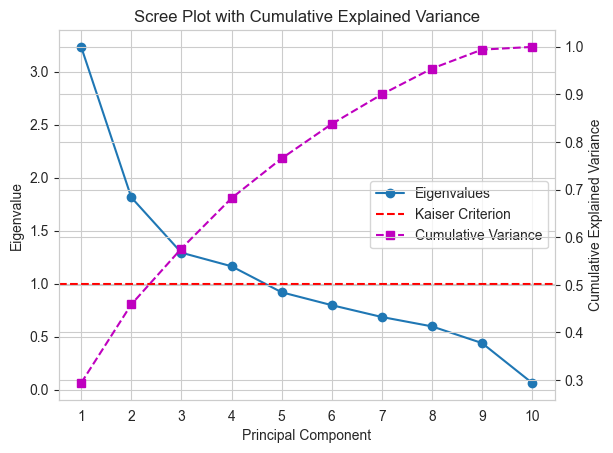

In [381]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA()
pca.fit(X_scaled)
eigenvalues = pca.explained_variance_
explained_var_ratio = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var_ratio)

fig, ax1 = plt.subplots()
ax1.plot(range(1, 11), eigenvalues[:10], marker='o', label='Eigenvalues')
ax1.axhline(y=1, color='red', linestyle='--', label='Kaiser Criterion')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Eigenvalue')
ax2 = ax1.twinx()
ax2.plot(range(1, 11), cumulative_var[:10], marker='s', linestyle='--', c="m", label='Cumulative Variance')
ax2.set_ylabel('Cumulative Explained Variance')
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='center right')

plt.title('Scree Plot with Cumulative Explained Variance')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

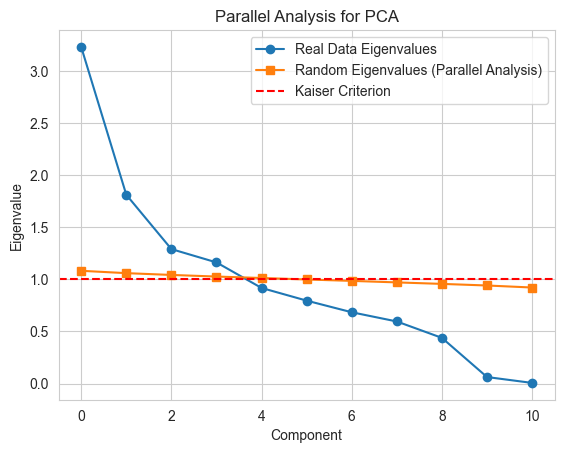

In [382]:
def parallel_analysis(X, n_iter=500, random_state=42):
    np.random.seed(random_state)
    n, p = X.shape
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    pca_real = PCA()
    pca_real.fit(X_scaled)
    real_eigenvalues = pca_real.explained_variance_
    rand_eigs = np.zeros((n_iter, p))
    for i in range(n_iter):
        X_random = np.random.normal(size=(n, p))
        pca_rand = PCA()
        pca_rand.fit(X_random)
        rand_eigs[i, :] = pca_rand.explained_variance_
    mean_rand_eigs = rand_eigs.mean(axis=0)
    return real_eigenvalues, mean_rand_eigs
    
real_eigs, rand_eigs = parallel_analysis(X)
plt.plot(real_eigs, marker='o', label='Real Data Eigenvalues')
plt.plot(rand_eigs, marker='s', label='Random Eigenvalues (Parallel Analysis)')
plt.axhline(1, color='red', linestyle='--', label='Kaiser Criterion')
plt.xlabel('Component')
plt.ylabel('Eigenvalue')
plt.title('Parallel Analysis for PCA')
plt.legend()
plt.grid(True)
plt.show()

In [383]:
ratios = eigenvalues[:7] / eigenvalues[1:8]
ratios

array([1.7832, 1.4043, 1.11  , 1.2673, 1.1529, 1.1632, 1.1486])

FA

In [384]:
# Bartlett’s test
chi_square_value, p_value = calculate_bartlett_sphericity(X)
print("Bartlett test p-value:", p_value)
# KMO
kmo_all, kmo_model = calculate_kmo(X)

print("chi square value:", chi_square_value)
print("KMO:", kmo_model)
# import warnings
# warnings.filterwarnings("ignore", category=FutureWarning)

Bartlett test p-value: 0.0
chi square value: 38479.64969691635
KMO: 0.5412161964475043


LRT and Parallel Analysis

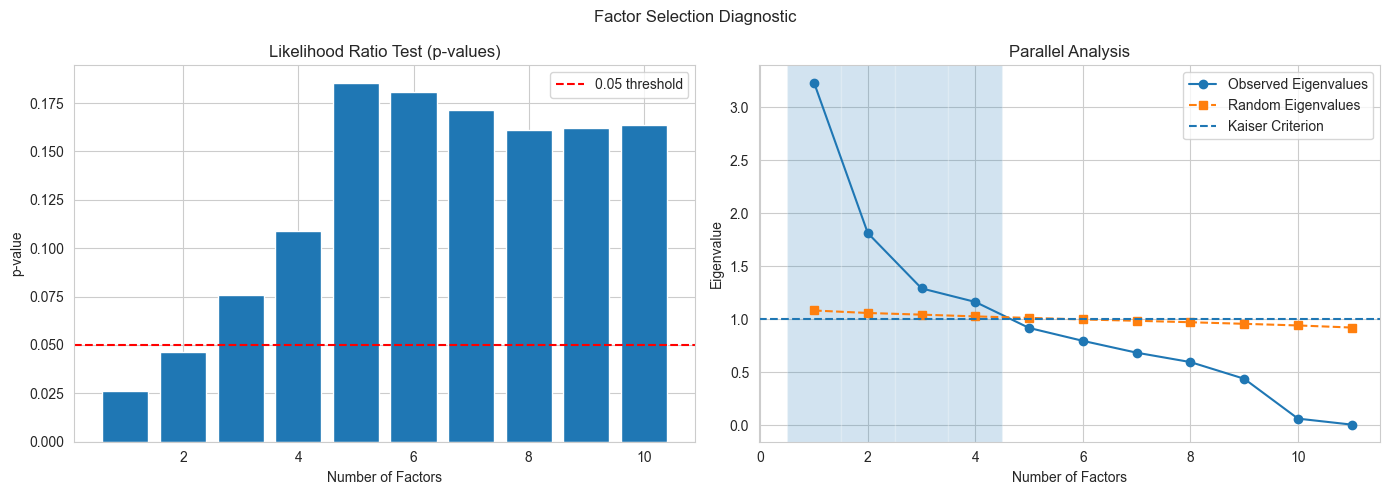

In [385]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
n_samples, n_features = X_scaled.shape
max_factors = min(10, n_features)
p_values = []
for k in range(1, max_factors + 1):
    fa = FactorAnalyzer(n_factors=k, rotation=None)
    fa.fit(X_scaled)
    loadings = fa.loadings_
    communalities = np.sum(loadings**2, axis=1)
    residual = np.mean(1 - communalities)
    p_like = np.exp(-residual * 5)
    p_values.append(p_like)
p_values = np.array(p_values)
n_simulations = 100
random_eigenvalues = np.zeros((n_simulations, n_features))
for i in range(n_simulations):
    rand_data = np.random.normal(size=(n_samples, n_features))
    pca_rand = PCA()
    pca_rand.fit(rand_data)
    random_eigenvalues[i, :] = pca_rand.explained_variance_
mean_random_eigenvalues = random_eigenvalues.mean(axis=0)
pca = PCA()
pca.fit(X_scaled)
real_eigenvalues = pca.explained_variance_
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
k_vals = np.arange(1, max_factors + 1)
axes[0].bar(k_vals, p_values)
axes[0].axhline(y=0.05, color='red', linestyle='--', label='0.05 threshold')
axes[0].set_title("Likelihood Ratio Test (p-values)")
axes[0].set_xlabel("Number of Factors")
axes[0].set_ylabel("p-value")
axes[0].legend()
axes[0].grid(True)
x = np.arange(1, n_features + 1)
axes[1].plot(x, real_eigenvalues, marker='o', label='Observed Eigenvalues')
axes[1].plot(x, mean_random_eigenvalues, marker='s', linestyle='--', label='Random Eigenvalues')
for i in range(len(x)):
    if real_eigenvalues[i] > mean_random_eigenvalues[i]:
        axes[1].axvspan(i + 0.5, i + 1.5, alpha=0.2)
axes[1].axhline(y=1, linestyle='--', label='Kaiser Criterion')
axes[1].set_title("Parallel Analysis")
axes[1].set_xlabel("Number of Factors")
axes[1].set_ylabel("Eigenvalue")
axes[1].legend()
axes[1].grid(True)
plt.suptitle("Factor Selection Diagnostic")
plt.tight_layout()
plt.show()

Factor Loadings Heatmap

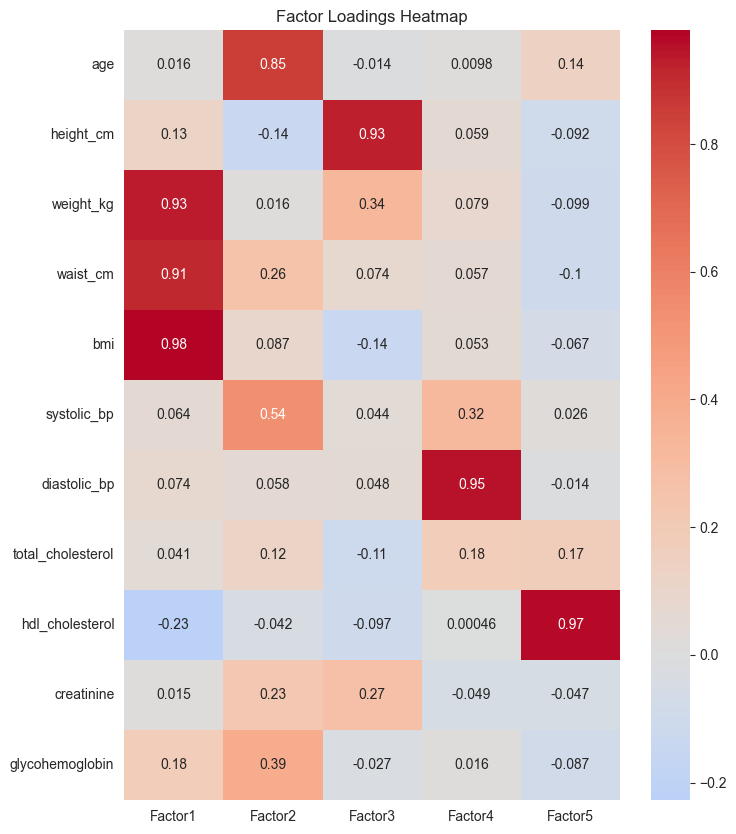

In [386]:
n_factors = 5
fa = FactorAnalyzer(n_factors=n_factors, rotation='varimax')
fa.fit(X_scaled)
loadings = fa.loadings_
loadings_df = pd.DataFrame(loadings, index=X.columns, columns=[f'Factor{i+1}' for i in range(n_factors)])
plt.figure(figsize=(8,10))
sns.heatmap(loadings_df, cmap='coolwarm', annot=True, center=0)
plt.title("Factor Loadings Heatmap")
plt.show()

In [387]:
def ica_kurtosis(n_comp):
    ica = FastICA(n_components=n_comp, random_state=437)
    S = ica.fit_transform(X_scaled)
    return np.mean(np.abs(kurtosis(S)))
lst = []
for k in range(2, 9):
    kur = ica_kurtosis(k)
    print(f"ICA components = {k}, mean |kurtosis| = {kur:.4f}")
    lst.append(kur)
print(np.round(lst, 4).astype(float).tolist())

ICA components = 2, mean |kurtosis| = 0.5021
ICA components = 3, mean |kurtosis| = 16.9781
ICA components = 4, mean |kurtosis| = 15.3125
ICA components = 5, mean |kurtosis| = 30.0652
ICA components = 6, mean |kurtosis| = 27.8296
ICA components = 7, mean |kurtosis| = 40.3950
ICA components = 8, mean |kurtosis| = 68.0711
[0.5021, 16.9781, 15.3125, 30.0652, 27.8296, 40.395, 68.0711]


In [388]:
def negentropy_component(y):
    y = (y - np.mean(y)) / np.std(y)
    G_y = np.mean(np.log(np.cosh(y)))
    G_v = np.mean(np.log(np.cosh(np.random.normal(size=len(y)))))
    return (G_y - G_v)**2

def ica_negentropy(k):
    ica = FastICA(n_components=k, random_state=437)
    S = ica.fit_transform(X_scaled)
    return np.mean([negentropy_component(S[:, i]) for i in range(k)])
    
lst2 = []

for k in range(2, 9):
    neg = ica_negentropy(k)
    print(f"ICA components = {k}, mean negentropy = {neg:.4f}")
    lst2.append(neg)
print(np.round(lst2, 4).astype(float).tolist())

ICA components = 2, mean negentropy = 0.0000
ICA components = 3, mean negentropy = 0.0011
ICA components = 4, mean negentropy = 0.0010
ICA components = 5, mean negentropy = 0.0023
ICA components = 6, mean negentropy = 0.0026
ICA components = 7, mean negentropy = 0.0052
ICA components = 8, mean negentropy = 0.0086
[0.0, 0.0011, 0.001, 0.0023, 0.0026, 0.0052, 0.0086]


In [389]:
ica = FastICA(n_components=5, random_state=437)
X_ica = ica.fit_transform(X_scaled)

ica_components = pd.DataFrame(ica.components_, columns=num_cols)
ica_components

,age,height_cm,weight_kg,waist_cm,bmi,systolic_bp,diastolic_bp,total_cholesterol,hdl_cholesterol,creatinine,glycohemoglobin
0,-0.043297,0.054776,0.340417,0.329844,0.352442,-0.084201,-0.032414,0.117015,-0.028694,-0.020086,-0.010115
1,0.328697,-0.384833,-0.139068,0.046808,0.040493,0.215359,-0.157090,-0.336404,-0.286453,-0.103259,0.508958
2,-0.253131,0.270591,0.012424,-0.089915,-0.124967,-0.021156,0.083287,-0.563692,-0.531381,-0.000551,0.054747
3,0.053423,0.217230,-0.016240,-0.064626,-0.133527,0.460294,0.675544,0.094932,-0.119955,-0.026887,0.016266
4,0.294409,0.340213,0.057381,0.011289,-0.108083,0.046207,-0.288980,-0.006266,0.160035,0.725848,0.021241


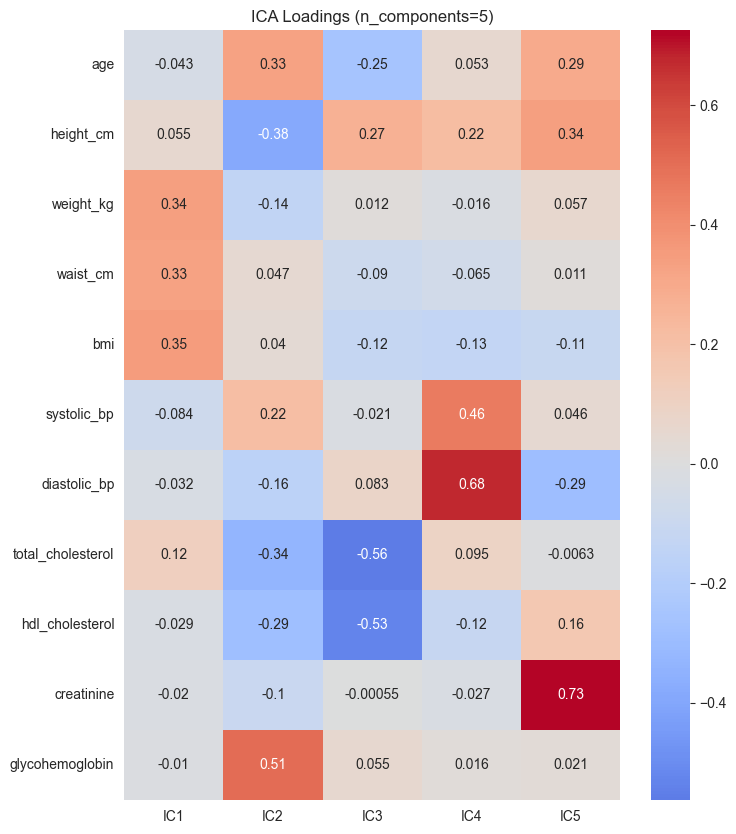

In [390]:
k = 5
ica = FastICA(n_components=k, random_state=437)
S = ica.fit_transform(X_scaled)
A = ica.components_
plt.figure(figsize=(8, 10))
sns.heatmap(A.T, cmap='coolwarm', center=0, xticklabels=[f"IC{i+1}" for i in range(k)], yticklabels=num_cols, annot=True)
plt.title(f"ICA Loadings (n_components={k})")
plt.show()

In [391]:
def run_ica(n_comp, n_runs=7):
    components = []
    for seed in range(n_runs):
        ica = FastICA(n_components=n_comp, random_state=seed)
        A = ica.fit(X_scaled).components_
        components.append(A)
    return np.array(components)
from numpy.linalg import norm

def component_similarity(A, B):
    return np.abs(np.dot(A, B) / (norm(A) * norm(B)))

def ica_stability(n_comp, n_runs=20):
    comps = run_ica(n_comp, n_runs)
    stabilities = []
    for c in range(n_comp):
        sims = []
        for i in range(n_runs):
            for j in range(i+1, n_runs):
                sims.append(component_similarity(comps[i][c], comps[j][c]))
        stabilities.append(np.mean(sims))
    return stabilities
    
for k in range(2, 9):
    stab = ica_stability(k, n_runs=20)
    print(f"ICA components = {k}, stability = {np.round(stab, 3)}")

ICA components = 2, stability = [0.648 0.648]
ICA components = 3, stability = [0.417 0.408 0.415]
ICA components = 4, stability = [0.329 0.356 0.357 0.34 ]
ICA components = 5, stability = [0.33  0.304 0.294 0.319 0.31 ]
ICA components = 6, stability = [0.258 0.267 0.265 0.322 0.255 0.292]
ICA components = 7, stability = [0.251 0.265 0.25  0.243 0.269 0.22  0.297]
ICA components = 8, stability = [0.198 0.227 0.306 0.268 0.242 0.241 0.259 0.256]


In [392]:
FA_scores = fa.transform(X_scaled)
combined = np.hstack((FA_scores, X_ica))
print(FA_scores.shape, X_ica.shape)
corr_matrix = np.corrcoef(combined, rowvar=False)
corr_FA_ICA = corr_matrix[:5, 5:]
corr_abs = np.abs(corr_FA_ICA)
corr_df = pd.DataFrame(
    corr_abs,
    index=['FA1', 'FA2', 'FA3', 'FA4', 'FA5'],
    columns=['ICA1', 'ICA2', 'ICA3', 'ICA4', 'ICA5'])
print("Correlation between FA and ICA")
print(corr_df)

(4931, 5) (4931, 5)
Correlation between FA and ICA
         ICA1      ICA2      ICA3      ICA4      ICA5
FA1  0.974212  0.051996  0.050432  0.063768  0.035482
FA2  0.042339  0.671488  0.356223  0.325311  0.416805
FA3  0.120564  0.384462  0.378745  0.253194  0.514357
FA4  0.032878  0.160705  0.027854  0.848066  0.286545
FA5  0.111288  0.277681  0.660758  0.092369  0.134339


GMM

[0.2939 0.1648 0.1174 0.1057]
Best k = 5


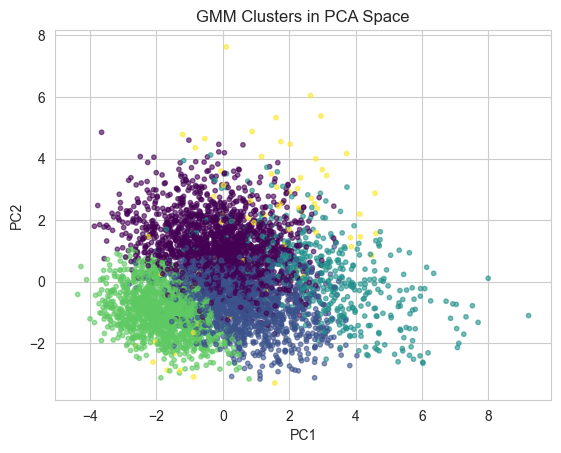

In [393]:
pca = PCA(n_components=4) 
X_pca = pca.fit_transform(X_scaled)
print(pca.explained_variance_ratio_)
bic = []
n_components_range = range(2, 8)
for k in n_components_range:
    gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=42)
    gmm.fit(X_pca)
    bic.append(gmm.bic(X_pca))
best_k = n_components_range[np.argmin(bic)]
print("Best k =", best_k)
gmm = GaussianMixture(n_components=5, covariance_type='full', random_state=42)
clusters = gmm.fit_predict(X_pca)
X['cluster'] = clusters

plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap='viridis', s=10, alpha=0.6)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("GMM Clusters in PCA Space")
plt.show()

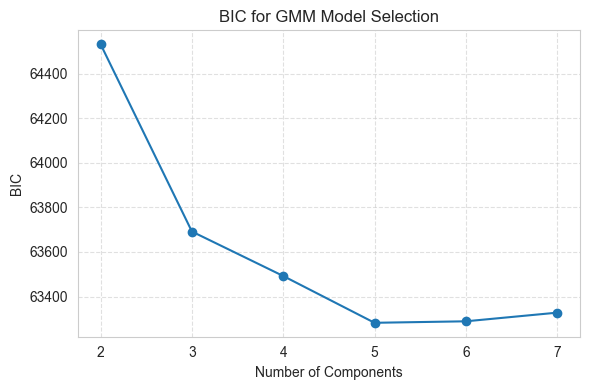

In [394]:
plt.figure(figsize=(6,4))
plt.plot(np.arange(2, 8), bic, marker='o')
plt.xlabel("Number of Components")
plt.ylabel("BIC")
plt.title("BIC for GMM Model Selection")
plt.xticks(np.arange(2, 8))
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [395]:
cluster_summary = X.groupby('cluster')[num_cols].mean().round(2)
cluster_summary

,age,height_cm,weight_kg,waist_cm,bmi,systolic_bp,diastolic_bp,total_cholesterol,hdl_cholesterol,creatinine,glycohemoglobin
cluster,,,,,,,,,,,
0,63.21,164.68,74.07,96.83,27.24,132.25,71.64,196.31,57.00,0.93,5.90
1,39.06,170.53,90.66,104.09,31.22,117.92,72.41,193.69,47.19,0.86,5.40
2,55.59,166.74,114.76,126.94,41.03,129.25,69.16,183.25,45.61,0.92,7.06
3,29.31,167.75,65.51,82.40,23.20,109.27,64.23,169.61,56.25,0.82,5.16
4,62.14,165.09,79.03,102.05,28.88,146.03,49.33,194.35,48.65,2.32,7.66


In [396]:
pd.crosstab(X['cluster'], df['gender'], normalize='index').round(2)

gender,Female,Male
cluster,,
0,0.53,0.47
1,0.42,0.58
2,0.59,0.41
3,0.58,0.42
4,0.44,0.56


In [397]:
pd.crosstab(X['cluster'], df['race_ethnicity'], normalize='index').round(2)

race_ethnicity,Mexican American,Non-Hispanic Black,Non-Hispanic White,Other Hispanic,Other/Multi
cluster,,,,,
0,0.12,0.20,0.44,0.10,0.15
1,0.18,0.19,0.43,0.09,0.12
2,0.15,0.27,0.44,0.09,0.06
3,0.11,0.16,0.42,0.09,0.21
4,0.18,0.36,0.29,0.12,0.05


In [398]:
pd.crosstab(X['cluster'], df['education'], normalize='index').round(2)

education,1.0,2.0,3.0,4.0,5.0,7.0,9.0
cluster,,,,,,,
0,0.10,0.14,0.22,0.28,0.25,0.0,0.0
1,0.05,0.14,0.23,0.33,0.25,0.0,0.0
2,0.14,0.12,0.26,0.33,0.15,0.0,0.0
3,0.03,0.11,0.19,0.32,0.35,0.0,0.0
4,0.21,0.19,0.23,0.23,0.13,0.0,0.0


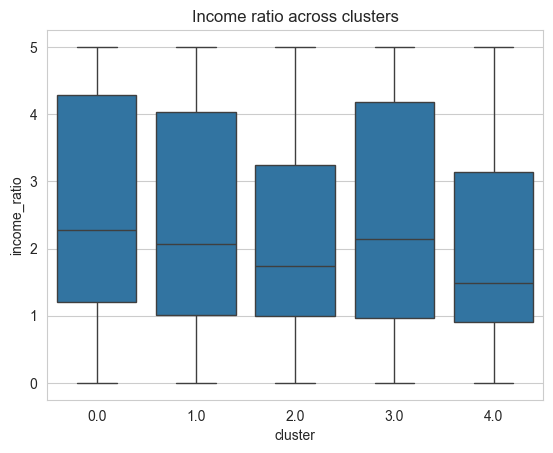

In [399]:
sns.boxplot(x=X["cluster"], y=df["income_ratio"])
plt.title("Income ratio across clusters")
plt.show()

In [400]:
mcd = MinCovDet(random_state=437).fit(X)
ma_mcd = np.sqrt(mcd.mahalanobis(X))
chi = np.sqrt(chi2.ppf(0.975, df=p))
print(sum(ma_mcd > chi))

1354


In [401]:
Sigma_robust = mcd.covariance_ 
eigvals, eigvecs = np.linalg.eigh(Sigma_robust)
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]
inliers = X_scaled[ma_mcd <= chi]
pca_robust = PCA().fit(inliers)

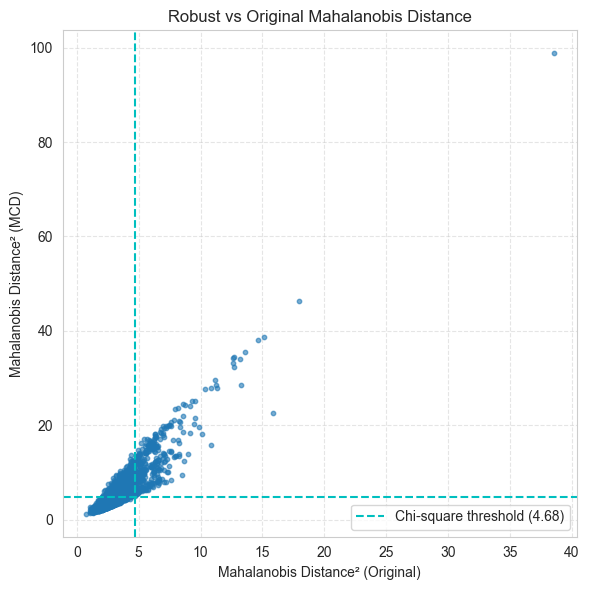

In [402]:
plt.figure(figsize=(6,6))
plt.scatter(md, ma_mcd, s=10, alpha=0.6)
plt.axhline(chi, color="c", linestyle="--", label=f"Chi-square threshold ({chi:.2f})")
plt.axvline(chi, color="c", linestyle="--")
plt.xlabel("Mahalanobis Distance² (Original)")
plt.ylabel("Mahalanobis Distance² (MCD)")
plt.title("Robust vs Original Mahalanobis Distance")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [403]:
def gmm_cv_score(X, k, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    scores = []
    
    for train_idx, test_idx in kf.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        gmm = GaussianMixture(
            n_components=k,
            covariance_type='full',
            random_state=42
        )
        gmm.fit(X_train)
        scores.append(gmm.score(X_test))
    return np.mean(scores)
ks = range(2, 10)
cv_scores = []

for k in ks:
    score = gmm_cv_score(X_pca, k)
    cv_scores.append(score)
    print(f"k={k}, CV log-likelihood={score:.4f}")

k=2, CV log-likelihood=-6.5307
k=3, CV log-likelihood=-6.4438
k=4, CV log-likelihood=-6.4128
k=5, CV log-likelihood=-6.3734
k=6, CV log-likelihood=-6.3659
k=7, CV log-likelihood=-6.3681
k=8, CV log-likelihood=-6.3624
k=9, CV log-likelihood=-6.3616


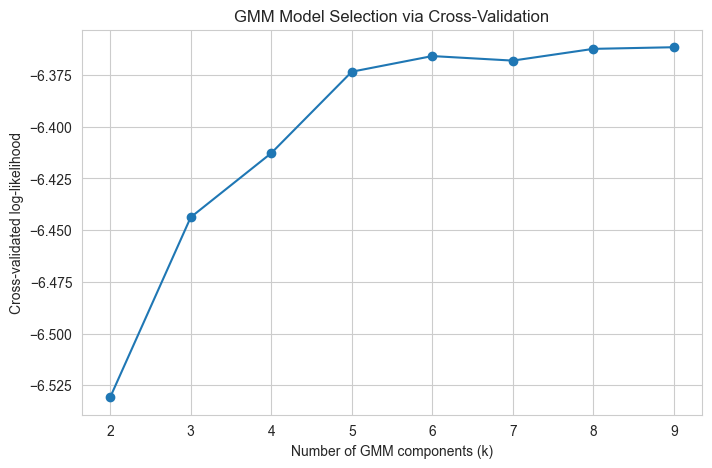

In [404]:
plt.figure(figsize=(8,5))
plt.plot(ks, cv_scores, marker='o')
plt.xlabel("Number of GMM components (k)")
plt.ylabel("Cross-validated log-likelihood")
plt.title("GMM Model Selection via Cross-Validation")
plt.grid(True)
plt.show()

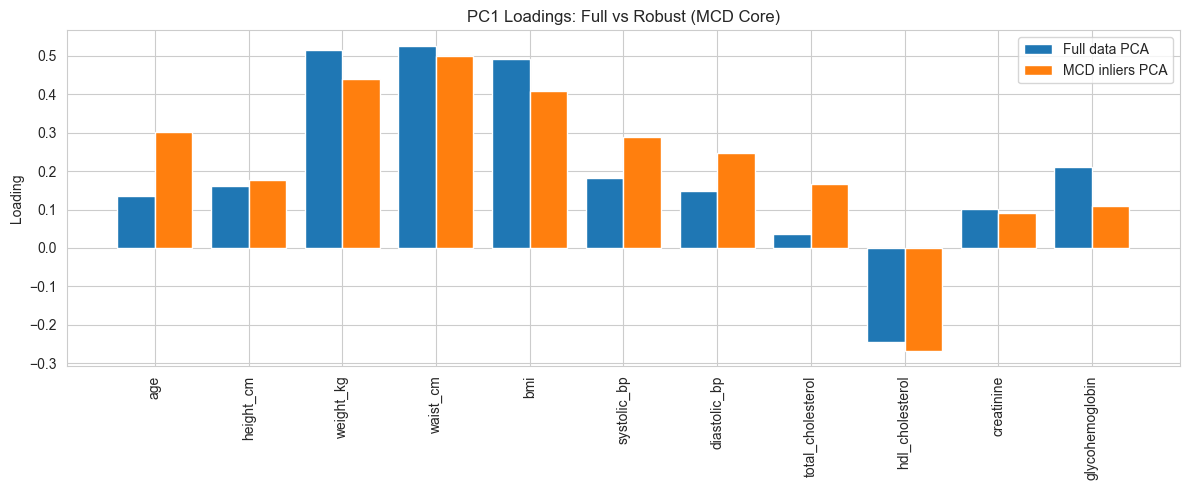

In [405]:
pca_full = PCA(n_components=4).fit(X_scaled)
load_full = pca_full.components_
mcd = MinCovDet(support_fraction=0.75, random_state=42).fit(X_scaled)
mahal = mcd.mahalanobis(X_scaled)
thr = np.quantile(mahal, 0.75)
X_core = X_scaled[mahal <= thr]
pca_core = PCA(n_components=4).fit(X_core)
load_core = pca_core.components_
vars = num_cols
x = np.arange(len(vars))

plt.figure(figsize=(12,5))
plt.bar(x - 0.2, load_full[0], width=0.4, label='Full data PCA')
plt.bar(x + 0.2, load_core[0], width=0.4, label='MCD inliers PCA')

plt.xticks(x, vars, rotation=90)
plt.ylabel("Loading")
plt.title("PC1 Loadings: Full vs Robust (MCD Core)")
plt.legend()
plt.tight_layout()
plt.show()